# 08. Evaluator-level Large error decomposition

기존 baseline/shared-E2E seed 42/43/44 checkpoint의 validation prediction을 저장하고, 실제 COCO evaluator의 score-order greedy matching 결과를 Large 객체 기준으로 분해합니다. **새 학습은 수행하지 않습니다.**

COCOeval의 `dtMatches`, `dtIgnore`, `gtMatches`, `gtIgnore`를 직접 사용하므로 TP/FP/FN과 AP/PR은 evaluator와 동일합니다. Non-ignored FP만 다음 우선순위로 세분화합니다.

1. `Duplicate FP`: 같은 class의 Large GT가 IoU threshold 이상이지만 이미 더 높은 score detection에 match됨
2. `Classification FP`: 다른 class의 Large GT와 IoU threshold 이상 겹침
3. `Localization FP`: 같은 class의 Large GT와 IoU 0.10 이상이지만 평가 threshold 미만
4. `Background FP`: 위 조건을 만족하지 않음

Localization/background 경계 `0.10`은 진단용으로 명시한 값이며, TP/FP/FN 및 AP 자체에는 영향을 주지 않습니다.


In [1]:
from pathlib import Path
import contextlib, gc, importlib, io, json, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoImageProcessor

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
eval_module = importlib.reload(eval_module)
ExperimentConfig = config_module.ExperimentConfig
DataBundle = data_module.DataBundle
VOCDataset = data_module.VOCDataset
collate_detection_batch = data_module.collate_detection_batch
parse_voc_record = data_module.parse_voc_record
load_checkpoint = eval_module.load_checkpoint
ID2LABEL = config_module.ID2LABEL


d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 설정

Validation 100장 전체와 세 seed를 사용합니다. 첫 실행 뒤 `RUN_INFERENCE=False`, `RUN_EVALUATION=False`로 바꾸면 저장된 CSV에서 표와 그래프만 다시 생성합니다.


In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, NUM_WORKERS = 2, 0
IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640
FEATURE_LEVEL = 0
IOU_THRESHOLDS = [0.50, 0.75]
BACKGROUND_IOU = 0.10
RUN_INFERENCE = True
RUN_EVALUATION = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE,
    feature_level=FEATURE_LEVEL,
)
SEED_TAG = '-'.join(map(str, SEEDS))
OUT = CONFIG.output_dir
PREDICTION_PATH = OUT / f'large_evaluator_predictions_seeds{SEED_TAG}.csv'
EVENT_PATH = OUT / f'large_evaluator_error_events_seeds{SEED_TAG}.csv'
METRICS_PATH = OUT / f'large_evaluator_metrics_seeds{SEED_TAG}.csv'
PR_PATH = OUT / f'large_evaluator_pr_curve_seeds{SEED_TAG}.csv'
ERROR_FIGURE_PATH = OUT / f'large_evaluator_error_types_seeds{SEED_TAG}.png'
PR_FIGURE_PATH = OUT / f'large_evaluator_pr_curve_seeds{SEED_TAG}.png'
DELTA_FIGURE_PATH = OUT / f'large_evaluator_seed_deltas_seeds{SEED_TAG}.png'
CONFIG.as_dict()


{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_e2e'],
 'seed': 42,
 'data_seed': 42}

## Validation GT와 checkpoint 확인

기존 split manifest를 읽어 동일한 validation subset을 복원하고 COCO-format GT를 메모리에 구성합니다. Category ID는 VOC label `0~19`에 1을 더해 저장합니다.


In [3]:
MANIFEST_PATH = OUT / 'voc2007_split_manifest.json'
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(MANIFEST_PATH)
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
if manifest.get('data_seed') != DATA_SEED:
    raise ValueError(f"manifest data_seed={manifest.get('data_seed')} != {DATA_SEED}")

checkpoint_rows = []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        path = CONFIG.checkpoint_path(experiment, seed)
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(),
            'size_mb': path.stat().st_size / 1024**2 if path.exists() else np.nan,
            'path': str(path),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
if not checkpoint_df['exists'].all():
    raise FileNotFoundError(checkpoint_df.loc[~checkpoint_df['exists'], 'path'].to_list())

val_ids = manifest['full_val_ids'][:VAL_IMAGES]
val_records = [parse_voc_record(CONFIG, str(image_id)) for image_id in tqdm(val_ids, desc='VOC val XML')]
try:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint, local_files_only=True)
except OSError:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint)
BUNDLE = DataBundle(processor, [], val_records, [], val_records)
collate_fn = lambda batch: collate_detection_batch(batch, BUNDLE.processor, CONFIG)
VAL_LOADER = DataLoader(
    VOCDataset(BUNDLE.val_records, CONFIG, training=False),
    batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(), collate_fn=collate_fn,
)

coco_images, coco_annotations = [], []
annotation_id = 1
for record in val_records:
    image_id = int(record['image_id'])
    coco_images.append({
        'id': image_id, 'width': int(record['width']), 'height': int(record['height']),
        'file_name': Path(record['image_path']).name,
    })
    for box, label in zip(record['boxes_xyxy'], record['labels']):
        x1, y1, x2, y2 = map(float, box)
        width, height = x2 - x1, y2 - y1
        coco_annotations.append({
            'id': annotation_id, 'image_id': image_id, 'category_id': int(label) + 1,
            'bbox': [x1, y1, width, height], 'area': width * height, 'iscrowd': 0,
        })
        annotation_id += 1
COCO_DATASET = {
    'info': {}, 'licenses': [],
    'images': coco_images, 'annotations': coco_annotations,
    'categories': [
        {'id': class_id + 1, 'name': ID2LABEL[class_id]} for class_id in sorted(ID2LABEL)
    ],
}
COCO_GT = COCO()
COCO_GT.dataset = COCO_DATASET
with contextlib.redirect_stdout(io.StringIO()):
    COCO_GT.createIndex()
IMAGE_IDS = [image['id'] for image in coco_images]
CATEGORY_IDS = [category['id'] for category in COCO_DATASET['categories']]
LARGE_GT_BY_IMAGE = {
    image_id: [
        annotation for annotation in coco_annotations
        if annotation['image_id'] == image_id and annotation['area'] >= 96**2
    ]
    for image_id in IMAGE_IDS
}
print({
    'val_images': len(IMAGE_IDS), 'all_gt': len(coco_annotations),
    'large_gt': sum(map(len, LARGE_GT_BY_IMAGE.values())), 'device': str(CONFIG.device),
})


,experiment,seed,exists,size_mb,path
0,baseline,42,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
1,shared_e2e,42,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
2,baseline,43,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
3,shared_e2e,43,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
4,baseline,44,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
5,shared_e2e,44,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...


VOC val XML: 100%|██████████| 100/100 [00:00<00:00, 2996.32it/s]

{'val_images': 100, 'all_gt': 311, 'large_gt': 190, 'device': 'cuda'}


## Prediction 저장

각 checkpoint의 processor post-processing 결과를 threshold 0으로 저장합니다. Deformable-DETR processor가 반환하는 image당 top-100 prediction set이 COCO evaluator 입력입니다.


In [4]:
def release_model(model):
    model.close()
    model.cpu()
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

@torch.inference_mode()
def collect_predictions(experiment, seed):
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval()
    rows = []
    try:
        for batch in tqdm(VAL_LOADER, desc=f'{experiment}/seed{seed}', leave=False):
            result = model(
                pixel_values=batch['pixel_values'].to(CONFIG.device, non_blocking=True),
                pixel_mask=batch['pixel_mask'].to(CONFIG.device, non_blocking=True), labels=None,
            )
            sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            predictions = BUNDLE.processor.post_process_object_detection(
                result['outputs'], threshold=0.0, target_sizes=sizes,
            )
            for prediction, target in zip(predictions, batch['eval_targets']):
                image_id = int(target['image_id'])
                for score, label, box in zip(
                    prediction['scores'].cpu(), prediction['labels'].cpu(), prediction['boxes'].cpu(),
                ):
                    x1, y1, x2, y2 = map(float, box.tolist())
                    rows.append({
                        'experiment': experiment, 'seed': seed, 'image_id': image_id,
                        'category_id': int(label) + 1, 'score': float(score),
                        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                        'area': max(x2 - x1, 0) * max(y2 - y1, 0),
                        'checkpoint_epoch': checkpoint.get('epoch'), 'fingerprint': fingerprint,
                    })
        return rows
    finally:
        release_model(model)


In [5]:
if RUN_INFERENCE:
    prediction_rows = []
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            prediction_rows.extend(collect_predictions(experiment, seed))
    prediction_df = pd.DataFrame(prediction_rows)
    prediction_df.insert(0, 'prediction_id', np.arange(1, len(prediction_df) + 1))
    prediction_df.to_csv(PREDICTION_PATH, index=False)
else:
    prediction_df = pd.read_csv(PREDICTION_PATH)
print('Saved/loaded:', PREDICTION_PATH, {'rows': len(prediction_df)})


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 19578.23it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_predictions_seeds42-43-44.csv {'rows': 60000}


## COCOeval 실행과 FP 세분화

TP/FP/FN은 Large area range에서 ignore되지 않은 evaluator 결과만 셉니다. 따라서 다른 area GT에 match된 detection과 Large 평가에서 area-ignore된 unmatched detection은 오류 집계에서 제외됩니다.


In [6]:
ERROR_TYPES = ['TP', 'Duplicate FP', 'Localization FP', 'Classification FP', 'Background FP', 'Missed GT']

def xywh_to_xyxy(box):
    x, y, width, height = map(float, box)
    return np.array([x, y, x + width, y + height], dtype=np.float64)

def iou_xyxy(box1, box2):
    left_top = np.maximum(box1[:2], box2[:2])
    right_bottom = np.minimum(box1[2:], box2[2:])
    wh = np.maximum(right_bottom - left_top, 0)
    intersection = wh[0] * wh[1]
    area1 = np.prod(np.maximum(box1[2:] - box1[:2], 0))
    area2 = np.prod(np.maximum(box2[2:] - box2[:2], 0))
    return intersection / max(area1 + area2 - intersection, 1e-12)

def make_coco_results(run_predictions):
    results = []
    for row in run_predictions.itertuples(index=False):
        results.append({
            'image_id': int(row.image_id), 'category_id': int(row.category_id),
            'bbox': [row.x1, row.y1, row.x2 - row.x1, row.y2 - row.y1],
            'score': float(row.score),
        })
    return results

def evaluate_run(experiment, seed, run_predictions):
    with contextlib.redirect_stdout(io.StringIO()):
        coco_dt = COCO_GT.loadRes(make_coco_results(run_predictions))
    evaluator = COCOeval(COCO_GT, coco_dt, iouType='bbox')
    evaluator.params.imgIds = IMAGE_IDS
    evaluator.params.catIds = CATEGORY_IDS
    evaluator.params.iouThrs = np.array(IOU_THRESHOLDS, dtype=np.float64)
    evaluator.params.maxDets = [1, 10, 100]
    with contextlib.redirect_stdout(io.StringIO()):
        evaluator.evaluate()
        evaluator.accumulate()

    large_index = evaluator.params.areaRngLbl.index('large')
    max_det_index = evaluator.params.maxDets.index(100)
    precision_tensor = evaluator.eval['precision']
    recall_tensor = evaluator.eval['recall']
    event_rows, metric_rows, pr_rows = [], [], []

    for threshold_index, threshold in enumerate(IOU_THRESHOLDS):
        precision_values = precision_tensor[threshold_index, :, :, large_index, max_det_index]
        valid_precision = precision_values[precision_values >= 0]
        ap_large = float(valid_precision.mean()) if valid_precision.size else np.nan
        recall_values = recall_tensor[threshold_index, :, large_index, max_det_index]
        valid_recall = recall_values[recall_values >= 0]
        coco_recall = float(valid_recall.mean()) if valid_recall.size else np.nan
        for recall_index, recall_threshold in enumerate(evaluator.params.recThrs):
            class_precisions = precision_tensor[
                threshold_index, recall_index, :, large_index, max_det_index
            ]
            valid = class_precisions[class_precisions >= 0]
            pr_rows.append({
                'experiment': experiment, 'seed': seed, 'iou_threshold': threshold,
                'recall_threshold': float(recall_threshold),
                'precision': float(valid.mean()) if valid.size else np.nan,
            })

        for eval_image in evaluator.evalImgs:
            if eval_image is None or eval_image['maxDet'] != 100:
                continue
            if list(eval_image['aRng']) != list(evaluator.params.areaRng[large_index]):
                continue
            image_id = int(eval_image['image_id'])
            category_id = int(eval_image['category_id'])
            dt_ids = np.asarray(eval_image['dtIds'], dtype=np.int64)
            gt_ids = np.asarray(eval_image['gtIds'], dtype=np.int64)
            dt_matches = np.asarray(eval_image['dtMatches'][threshold_index])
            gt_matches = np.asarray(eval_image['gtMatches'][threshold_index])
            dt_ignore = np.asarray(eval_image['dtIgnore'][threshold_index], dtype=bool)
            gt_ignore = np.asarray(eval_image['gtIgnore'], dtype=bool)
            matched_large_gt_ids = set(
                int(gt_id) for gt_id, matched, ignored in zip(gt_ids, gt_matches, gt_ignore)
                if matched > 0 and not ignored
            )

            for detection_index, detection_id in enumerate(dt_ids):
                if dt_ignore[detection_index]:
                    continue
                detection = coco_dt.anns[int(detection_id)]
                if dt_matches[detection_index] > 0:
                    matched_gt_id = int(dt_matches[detection_index])
                    matched_gt = COCO_GT.anns[matched_gt_id]
                    matched_iou = iou_xyxy(
                        xywh_to_xyxy(detection['bbox']), xywh_to_xyxy(matched_gt['bbox']),
                    )
                    event_rows.append({
                        'experiment': experiment, 'seed': seed, 'iou_threshold': threshold,
                        'image_id': image_id, 'category_id': category_id,
                        'event_type': 'TP', 'score': float(detection['score']),
                        'detection_id': int(detection_id), 'gt_id': matched_gt_id,
                        'best_iou': matched_iou,
                    })
                    continue

                detection_box = xywh_to_xyxy(detection['bbox'])
                large_gts = LARGE_GT_BY_IMAGE[image_id]
                overlaps = [
                    (gt, iou_xyxy(detection_box, xywh_to_xyxy(gt['bbox']))) for gt in large_gts
                ]
                same_class = [(gt, overlap) for gt, overlap in overlaps if gt['category_id'] == category_id]
                wrong_class = [(gt, overlap) for gt, overlap in overlaps if gt['category_id'] != category_id]
                duplicate_candidates = [
                    (gt, overlap) for gt, overlap in same_class
                    if overlap >= threshold and gt['id'] in matched_large_gt_ids
                ]
                classification_candidates = [
                    (gt, overlap) for gt, overlap in wrong_class if overlap >= threshold
                ]
                localization_candidates = [
                    (gt, overlap) for gt, overlap in same_class
                    if BACKGROUND_IOU <= overlap < threshold
                ]
                if duplicate_candidates:
                    event_type, candidate = 'Duplicate FP', max(duplicate_candidates, key=lambda item: item[1])
                elif classification_candidates:
                    event_type, candidate = 'Classification FP', max(classification_candidates, key=lambda item: item[1])
                elif localization_candidates:
                    event_type, candidate = 'Localization FP', max(localization_candidates, key=lambda item: item[1])
                else:
                    event_type, candidate = 'Background FP', (None, max([value for _, value in overlaps], default=0.0))
                candidate_gt, best_iou = candidate
                event_rows.append({
                    'experiment': experiment, 'seed': seed, 'iou_threshold': threshold,
                    'image_id': image_id, 'category_id': category_id,
                    'event_type': event_type, 'score': float(detection['score']),
                    'detection_id': int(detection_id),
                    'gt_id': int(candidate_gt['id']) if candidate_gt is not None else np.nan,
                    'best_iou': float(best_iou),
                })

            for gt_id, matched, ignored in zip(gt_ids, gt_matches, gt_ignore):
                if matched == 0 and not ignored:
                    event_rows.append({
                        'experiment': experiment, 'seed': seed, 'iou_threshold': threshold,
                        'image_id': image_id, 'category_id': category_id,
                        'event_type': 'Missed GT', 'score': np.nan,
                        'detection_id': np.nan, 'gt_id': int(gt_id), 'best_iou': np.nan,
                    })

        threshold_events = [row for row in event_rows if row['iou_threshold'] == threshold]
        counts = pd.Series([row['event_type'] for row in threshold_events]).value_counts()
        tp = int(counts.get('TP', 0))
        missed = int(counts.get('Missed GT', 0))
        fp = sum(int(counts.get(name, 0)) for name in ERROR_TYPES[1:5])
        metric_rows.append({
            'experiment': experiment, 'seed': seed, 'iou_threshold': threshold,
            **{name: int(counts.get(name, 0)) for name in ERROR_TYPES},
            'Precision_micro': tp / max(tp + fp, 1),
            'Recall_micro': tp / max(tp + missed, 1),
            'Recall_COCO_macro': coco_recall, 'AP_L': ap_large,
        })
    return event_rows, metric_rows, pr_rows


In [7]:
if RUN_EVALUATION:
    all_event_rows, all_metric_rows, all_pr_rows = [], [], []
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            run_predictions = prediction_df.query('seed == @seed and experiment == @experiment')
            event_rows, metric_rows, pr_rows = evaluate_run(experiment, seed, run_predictions)
            all_event_rows.extend(event_rows)
            all_metric_rows.extend(metric_rows)
            all_pr_rows.extend(pr_rows)
    event_df = pd.DataFrame(all_event_rows)
    metrics_df = pd.DataFrame(all_metric_rows)
    pr_df = pd.DataFrame(all_pr_rows)
    event_df.to_csv(EVENT_PATH, index=False)
    metrics_df.to_csv(METRICS_PATH, index=False)
    pr_df.to_csv(PR_PATH, index=False)
else:
    event_df = pd.read_csv(EVENT_PATH)
    metrics_df = pd.read_csv(METRICS_PATH)
    pr_df = pd.read_csv(PR_PATH)
print('Saved/loaded:', EVENT_PATH, METRICS_PATH, PR_PATH)
display(metrics_df)


Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_error_events_seeds42-43-44.csv D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_metrics_seeds42-43-44.csv D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_pr_curve_seeds42-43-44.csv


,experiment,seed,iou_threshold,TP,Duplicate FP,Localization FP,Classification FP,Background FP,Missed GT,Precision_micro,Recall_micro,Recall_COCO_macro,AP_L
0,baseline,42,0.50,156,1610,550,4425,1133,34,0.019812,0.821053,0.655150,0.159737
1,baseline,42,0.75,129,765,1454,3215,2311,61,0.016383,0.678947,0.541816,0.106680
2,shared_e2e,42,0.50,156,1529,458,4880,799,34,0.019944,0.821053,0.674590,0.170846
3,shared_e2e,42,0.75,134,644,1389,3355,2299,56,0.017133,0.705263,0.526083,0.108336
4,baseline,43,0.50,171,1217,463,4951,1022,19,0.021856,0.900000,0.810467,0.255451
5,baseline,43,0.75,144,437,1319,3140,2784,46,0.018405,0.757895,0.654920,0.207304
6,shared_e2e,43,0.50,157,1454,432,4924,736,33,0.020382,0.826316,0.689249,0.215280
7,shared_e2e,43,0.75,129,589,1362,3362,2261,61,0.016747,0.678947,0.477861,0.138678
8,baseline,44,0.50,141,1627,531,4000,966,49,0.019408,0.742105,0.562066,0.164248
9,baseline,44,0.75,119,714,1491,2532,2412,71,0.016373,0.626316,0.468027,0.128582


## 1. Large TP/FP error type bar chart

막대와 오차선은 세 seed의 평균과 표준편차입니다. Missed GT는 별도 표와 seed-delta 그래프에서 함께 비교합니다.


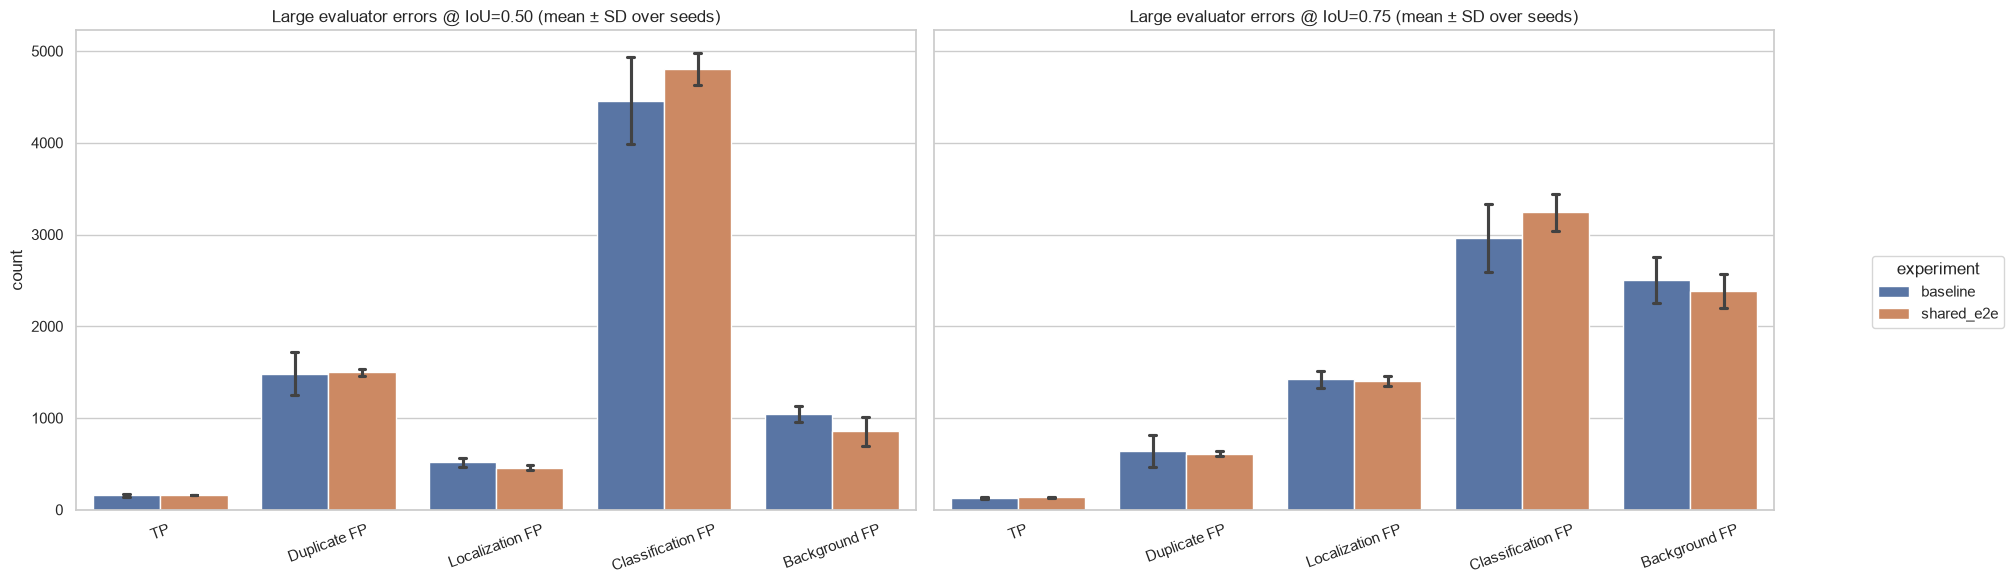

Saved: D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_error_types_seeds42-43-44.png


In [8]:
COUNT_TYPES = ['TP', 'Duplicate FP', 'Localization FP', 'Classification FP', 'Background FP']
count_plot_df = metrics_df.melt(
    id_vars=['experiment', 'seed', 'iou_threshold'], value_vars=COUNT_TYPES,
    var_name='error_type', value_name='count',
)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
for axis, threshold in zip(axes, IOU_THRESHOLDS):
    sns.barplot(
        data=count_plot_df.query('iou_threshold == @threshold'),
        x='error_type', y='count', hue='experiment',
        estimator='mean', errorbar='sd', capsize=0.08, ax=axis,
    )
    axis.set_title(f'Large evaluator errors @ IoU={threshold:.2f} (mean ± SD over seeds)')
    axis.set_xlabel('')
    axis.set_ylabel('count' if axis is axes[0] else '')
    axis.tick_params(axis='x', rotation=20)
handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    if axis.get_legend() is not None:
        axis.get_legend().remove()
fig.legend(handles, labels, title='experiment', loc='center right', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(ERROR_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', ERROR_FIGURE_PATH)


## 2. Large Precision–Recall curve

COCO의 101-point interpolated precision을 class 평균한 Large PR curve입니다. 선은 seed 평균, 음영은 seed 표준편차입니다.


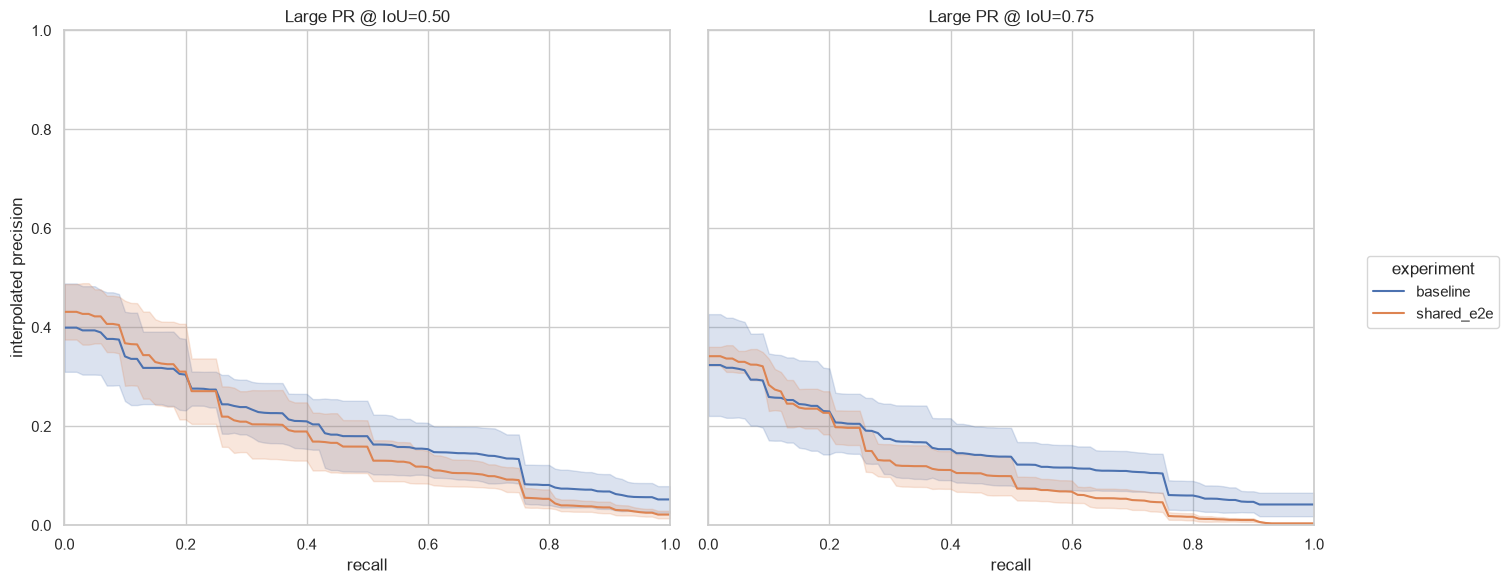

Saved: D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_pr_curve_seeds42-43-44.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for axis, threshold in zip(axes, IOU_THRESHOLDS):
    sns.lineplot(
        data=pr_df.query('iou_threshold == @threshold'),
        x='recall_threshold', y='precision', hue='experiment',
        estimator='mean', errorbar='sd', ax=axis,
    )
    axis.set_title(f'Large PR @ IoU={threshold:.2f}')
    axis.set_xlabel('recall')
    axis.set_ylabel('interpolated precision' if axis is axes[0] else '')
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    if axis.get_legend() is not None:
        axis.get_legend().remove()
fig.legend(handles, labels, title='experiment', loc='center right', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(PR_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', PR_FIGURE_PATH)


## 3. Large IoU=.50 / .75 error decomposition 표

Count와 `Recall_micro`는 전체 Large GT/detection을 합친 micro 지표이고, `AP_L`과 `Recall_COCO_macro`는 COCO 방식의 class 평균입니다. 요청 표의 Recall은 `Recall_micro`로 표시합니다.


In [10]:
TABLE_METRICS = ERROR_TYPES + ['Precision_micro', 'Recall_micro', 'AP_L']
decomposition_tables = {}
for threshold in IOU_THRESHOLDS:
    threshold_df = metrics_df.query('iou_threshold == @threshold')
    means = threshold_df.groupby('experiment')[TABLE_METRICS].mean().T
    means['Delta'] = means['shared_e2e'] - means['baseline']
    means = means.rename(columns={'baseline': 'Baseline', 'shared_e2e': 'Shared E2E'})
    decomposition_tables[threshold] = means
    formatters = {
        'Baseline': '{:.4f}', 'Shared E2E': '{:.4f}', 'Delta': '{:+.4f}',
    }
    display(means.style.format(formatters).set_caption(f'Large @ IoU={threshold:.2f}: seed mean'))


experiment,Baseline,Shared E2E,Delta
TP,156.0000,156.3333,+0.3333
Duplicate FP,1484.6667,1499.0000,+14.3333
Localization FP,514.6667,458.3333,-56.3333
Classification FP,4458.6667,4803.6667,+345.0000
Background FP,1040.3333,856.6667,-183.6667
Missed GT,34.0000,33.6667,-0.3333
Precision_micro,0.0204,0.0201,-0.0002
Recall_micro,0.8211,0.8228,+0.0018
AP_L,0.1931,0.1750,-0.0181


experiment,Baseline,Shared E2E,Delta
TP,130.6667,133.3333,+2.6667
Duplicate FP,638.6667,610.0000,-28.6667
Localization FP,1421.3333,1403.6667,-17.6667
Classification FP,2962.3333,3241.6667,+279.3333
Background FP,2502.3333,2386.0000,-116.3333
Missed GT,59.3333,56.6667,-2.6667
Precision_micro,0.0171,0.0171,+0.0001
Recall_micro,0.6877,0.7018,+0.0140
AP_L,0.1475,0.1157,-0.0318


## 4. Seed별 Shared-E2E − Baseline 변화

위쪽은 TP/FP/FN count 변화, 아래쪽은 AP와 recall 변화입니다. 0보다 크면 Shared-E2E가 더 큰 값입니다.


,seed,iou_threshold,delta_TP,delta_Duplicate FP,delta_Localization FP,delta_Classification FP,delta_Background FP,delta_Missed GT,delta_Precision_micro,delta_Recall_micro,delta_AP_L
0,42,0.50,0,-81,-92,455,-334,0,0.000132,0.000000,0.011109
1,42,0.75,5,-121,-65,140,-12,-5,0.000750,0.026316,0.001656
2,43,0.50,-14,237,-31,-27,-286,14,-0.001474,-0.073684,-0.040171
3,43,0.75,-15,152,43,222,-523,15,-0.001658,-0.078947,-0.068626
4,44,0.50,15,-113,-46,607,69,-15,0.000600,0.078947,-0.025239
5,44,0.75,18,-117,-31,476,186,-18,0.001191,0.094737,-0.028569


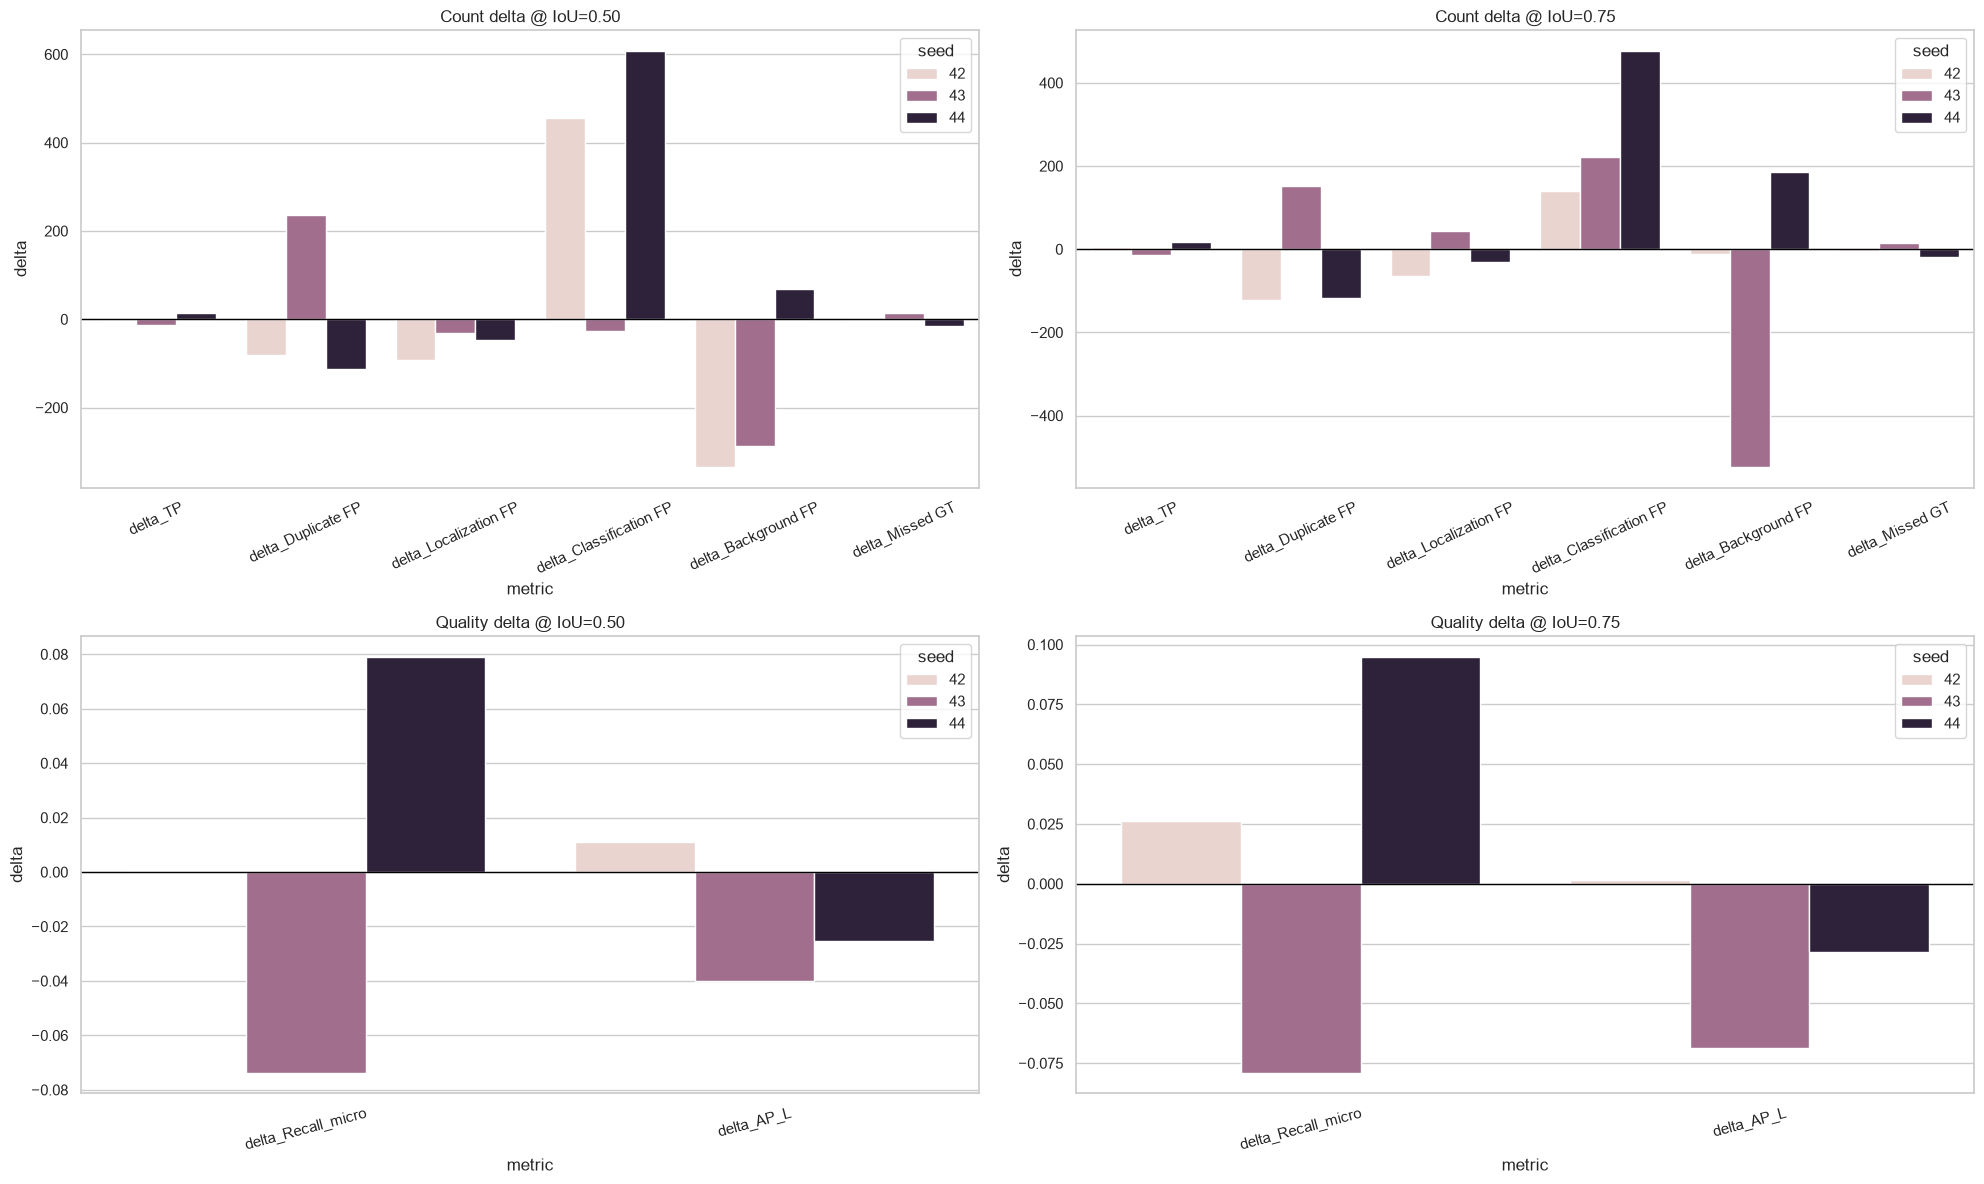

Saved: D:\gt-super\outputs\detr_gt_auxiliary\large_evaluator_seed_deltas_seeds42-43-44.png


In [11]:
baseline_metrics = (
    metrics_df.query("experiment == 'baseline'")
    [['seed', 'iou_threshold'] + TABLE_METRICS]
    .rename(columns={metric: f'baseline_{metric}' for metric in TABLE_METRICS})
)
delta_df = metrics_df.query("experiment == 'shared_e2e'").merge(
    baseline_metrics, on=['seed', 'iou_threshold'], how='left',
)
for metric in TABLE_METRICS:
    delta_df[f'delta_{metric}'] = delta_df[metric] - delta_df[f'baseline_{metric}']
display(delta_df[['seed', 'iou_threshold'] + [f'delta_{metric}' for metric in TABLE_METRICS]])

count_delta_plot = delta_df.melt(
    id_vars=['seed', 'iou_threshold'],
    value_vars=[f'delta_{metric}' for metric in ERROR_TYPES],
    var_name='metric', value_name='delta',
)
quality_delta_plot = delta_df.melt(
    id_vars=['seed', 'iou_threshold'],
    value_vars=['delta_Recall_micro', 'delta_AP_L'],
    var_name='metric', value_name='delta',
)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for column, threshold in enumerate(IOU_THRESHOLDS):
    sns.barplot(
        data=count_delta_plot.query('iou_threshold == @threshold'),
        x='metric', y='delta', hue='seed', ax=axes[0, column],
    )
    axes[0, column].axhline(0, color='black', linewidth=1)
    axes[0, column].set_title(f'Count delta @ IoU={threshold:.2f}')
    axes[0, column].tick_params(axis='x', rotation=25)
    sns.barplot(
        data=quality_delta_plot.query('iou_threshold == @threshold'),
        x='metric', y='delta', hue='seed', ax=axes[1, column],
    )
    axes[1, column].axhline(0, color='black', linewidth=1)
    axes[1, column].set_title(f'Quality delta @ IoU={threshold:.2f}')
    axes[1, column].tick_params(axis='x', rotation=15)
plt.tight_layout()
fig.savefig(DELTA_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', DELTA_FIGURE_PATH)


## 자동 요약

IoU=.75에서 Shared-E2E의 baseline 대비 평균 변화가 가장 큰 evaluator error type을 출력합니다. 단순 count 크기뿐 아니라 AP/recall과 seed 일관성을 함께 확인해야 합니다.


In [12]:
delta75 = delta_df.query('iou_threshold == 0.75')
mean_error_deltas75 = {
    metric: float(delta75[f'delta_{metric}'].mean()) for metric in ERROR_TYPES
}
increased_failures75 = {
    metric: value for metric, value in mean_error_deltas75.items()
    if metric != 'TP' and value > 0
}
dominant_increase75 = max(increased_failures75, key=increased_failures75.get) if increased_failures75 else None
print({
    'mean_error_deltas_at_075': mean_error_deltas75,
    'dominant_increased_failure_at_075': dominant_increase75,
    'delta_recall_micro_at_075': float(delta75['delta_Recall_micro'].mean()),
    'delta_AP75_L': float(delta75['delta_AP_L'].mean()),
})


{'mean_error_deltas_at_075': {'TP': 2.6666666666666665, 'Duplicate FP': -28.666666666666668, 'Localization FP': -17.666666666666668, 'Classification FP': 279.3333333333333, 'Background FP': -116.33333333333333, 'Missed GT': -2.6666666666666665}, 'dominant_increased_failure_at_075': 'Classification FP', 'delta_recall_micro_at_075': 0.014035087719298253, 'delta_AP75_L': -0.03184636054815855}
